# Progress Submission Notebook

## Customer Behaviour Profiling & Micro-Segmentation

### Problem Statement & Business Goal 

#### Problem Statement

Retail businesses generate large amounts of transactional customer data, but identifying meaningful customer groups and understanding shopping behavior remains a challenge. This project aims to analyze customer purchasing patterns and perform micro-segmentation using clustering techniques based on RFM metrics, Average Basket Size, and Product Diversity to identify distinct customer behavior profiles.

#### Business Goals

- Identify customer segments based on purchasing behavior  
- Understand customer spending and engagement patterns  
- Profile high-value, loyal, and churn-risk customers  
- Support targeted marketing and personalized offers  
- Improve customer retention and business decision-making  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style='whitegrid')

# Download the Online Retail II dataset from Kaggle
path = kagglehub.dataset_download("jillwang87/online-retail-ii")

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(path + "/online_retail_09_10.csv")

df.head()

100%|██████████| 14.2M/14.2M [00:07<00:00, 1.93MB/s]

Extracting files...


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


### 1. Dataset Overview

- **Dataset Name:** UCI Online Retail II Data Set  
- **Source:** Kaggle
- **Dataset Link:** https://www.kaggle.com/datasets/jillwang87/online-retail-ii  

### 2. Data Inspection & Audit

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   UnitPrice    525461 non-null  float64
 6   CustomerID   417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


#### Initial Understanding & Observations

- The dataset contains **525,461 retail transaction records** with 8 features related to invoices, products, customers, pricing, and geographic information.

- The dataset includes both **categorical** and **numerical** variables:
  - Numerical: Quantity, UnitPrice
  - Categorical: InvoiceNo, StockCode, Description, CustomerID, Country

- `InvoiceDate` is currently stored as an object datatype and requires conversion to datetime format for time-based analysis such as Recency calculation and purchase trend analysis.

- `CustomerID` contains **107,927 missing values**, which is significant because customer-level behavioral profiling and segmentation depend heavily on customer identification.

- `Description` contains **2,928 missing values**, indicating some products lack descriptions, which may affect product-level analysis.

- Other columns have no missing values, indicating relatively stable transactional information.

- The dataset contains:
  - 28,816 unique invoices
  - 4,632 unique products
  - 4,383 unique customers
  - Customers from 40 different countries

- The high number of unique invoices and products indicates rich transactional diversity suitable for customer behavior analysis and micro-segmentation.

- Multiple purchases by the same customers suggest the dataset is appropriate for RFM analysis and customer profiling.

- The dataset appears to represent real-world retail transactional data, which may include cancellations, returns, duplicate transactions, and noisy records that require preprocessing before clustering and behavioral analysis.

- The presence of transactional, customer, and product-level information makes the dataset highly suitable for:
  - Customer segmentation
  - Behavioral profiling
  - RFM analysis
  - Spending pattern analysis
  - Customer retention analysis
  - Personalized marketing insights

### 3. Data Preprocessing (DPP)

In [5]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove rows with missing Description
df = df.dropna(subset=['Description'])

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# Remove zero or negative prices
df = df[df['UnitPrice'] > 0]

In [6]:
# Convert Customer ID column to string datatype
df['CustomerID'] = df['CustomerID'].astype(str)

In [7]:
# Convert InvoiceDate column to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407664 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    407664 non-null  object        
 1   StockCode    407664 non-null  object        
 2   Description  407664 non-null  object        
 3   Quantity     407664 non-null  int64         
 4   InvoiceDate  407664 non-null  datetime64[ns]
 5   UnitPrice    407664 non-null  float64       
 6   CustomerID   407664 non-null  object        
 7   Country      407664 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 28.0+ MB


#### To ensure reliable customer behavior analysis, the dataset was cleaned by:

- Removing records with missing `CustomerID`
- Removing records with missing `Description`
- Excluding transactions with non-positive quantities
- Excluding transactions with non-positive unit prices

These steps ensure that only valid purchase transactions are retained for feature engineering and customer segmentation.

### 4. Feature Engineering

In [9]:
# Create TotalAmount feature by multiplying Quantity and UnitPrice
# Represents the total spending value for each transaction record
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [10]:
df.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4


In [11]:
# Reference date for Recency calculation
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2010-12-10 20:01:00')

In [12]:
# ==============================
# RFM Feature Creation
# ==============================

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Display first rows
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [13]:
# ==============================
# Average Basket Size
# ==============================

basket_size = df.groupby('CustomerID')['Quantity'].mean().reset_index()

basket_size.columns = ['CustomerID', 'AvgBasketSize']


# ==============================
# Product Diversity
# ==============================

product_diversity = df.groupby('CustomerID')['StockCode'].nunique().reset_index()

product_diversity.columns = ['CustomerID', 'ProductDiversity']


# ==============================
# Average Order Value
# ==============================

avg_order_value = df.groupby('CustomerID')['TotalAmount'].mean().reset_index()

avg_order_value.columns = ['CustomerID', 'AvgOrderValue']

In [14]:
# Merge additional features
rfm = rfm.merge(basket_size, on='CustomerID')
rfm = rfm.merge(product_diversity, on='CustomerID')
rfm = rfm.merge(avg_order_value, on='CustomerID')

# Display updated dataframe
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,ProductDiversity,AvgOrderValue
0,12346.0,165,11,372.86,2.121212,26,11.298788
1,12347.0,3,2,1323.32,11.661972,70,18.638310
2,12348.0,74,1,222.16,18.650000,20,11.108000
3,12349.0,43,3,2671.14,9.735294,90,26.187647
4,12351.0,11,1,300.93,12.428571,21,14.330000


#### Created / Transformed Features

To perform customer behavior profiling and micro-segmentation, transaction-level data was aggregated into customer-level behavioral metrics. These engineered features capture purchasing habits, spending patterns, and product preferences.

#### 1. Recency

**Definition:** Number of days since a customer's most recent purchase.

**Formula:**
```
Recency = Reference Date − Last Purchase Date
```

**Business Interpretation:**
Lower values indicate recently active customers, while higher values may indicate inactive or churn-risk customers.

---

#### 2. Frequency

**Definition:** Total number of unique purchase transactions made by a customer.

**Formula:**
```
Frequency = Count of Unique Invoices
```

**Business Interpretation:**
Customers with higher frequency tend to be more engaged and loyal.

---

#### 3. Monetary

**Definition:** Total revenue generated by a customer.

**Formula:**
```
Monetary = Sum(Quantity × Price)
```

**Business Interpretation:**
Measures the overall financial contribution of a customer.

---

#### 4. AvgBasketSize

**Definition:** Average number of items purchased per transaction.

**Formula:**
```
AvgBasketSize = Total Quantity Purchased / Frequency
```

**Business Interpretation:**
Indicates the typical volume of products purchased in each order.

---

#### 5. ProductDiversity

**Definition:** Number of unique products purchased by a customer.

**Formula:**
```
ProductDiversity = Count of Unique Product Descriptions
```

**Business Interpretation:**
Measures the breadth of customer interests and purchasing variety. Higher values indicate exploration across multiple product categories.

---

#### 6. AvgOrderValue

**Definition:** Average monetary value of each transaction.

**Formula:**
```
AvgOrderValue = Monetary / Frequency
```

**Business Interpretation:**
Helps distinguish customers who make high-value purchases from those who make frequent but lower-value purchases.

---

#### Why These Features?

These features transform raw transaction records into meaningful customer-level behavioral indicators:

- **Recency** captures customer freshness.
- **Frequency** captures engagement.
- **Monetary** captures customer value.
- **AvgBasketSize** captures purchasing volume.
- **ProductDiversity** captures variety of interests.
- **AvgOrderValue** captures spending intensity.

Together, these metrics provide a comprehensive view of customer behavior and serve as inputs for clustering algorithms to identify distinct customer segments.

### 5. Exploratory Data Analysis (EDA)

In [16]:
rfm.head()
rfm.shape
rfm.info()
rfm.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        4312 non-null   object 
 1   Recency           4312 non-null   int64  
 2   Frequency         4312 non-null   int64  
 3   Monetary          4312 non-null   float64
 4   AvgBasketSize     4312 non-null   float64
 5   ProductDiversity  4312 non-null   int64  
 6   AvgOrderValue     4312 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 235.9+ KB


,count,mean,std,min,25%,50%,75%,max
Recency,4312.0,91.171846,96.860633,1.000000,18.000000,53.000000,136.000000,374.000000
Frequency,4312.0,4.455705,8.170213,1.000000,1.000000,2.000000,5.000000,205.000000
Monetary,4312.0,2048.238236,8914.481280,2.950000,307.987500,706.020000,1723.142500,349164.350000
AvgBasketSize,4312.0,21.471799,115.061014,1.000000,5.268097,9.343294,14.234503,4460.294118
ProductDiversity,4312.0,63.646104,85.757966,1.000000,17.000000,38.000000,79.250000,1741.000000
AvgOrderValue,4312.0,36.961744,217.711120,1.993684,11.112076,17.351923,24.839503,10953.500000


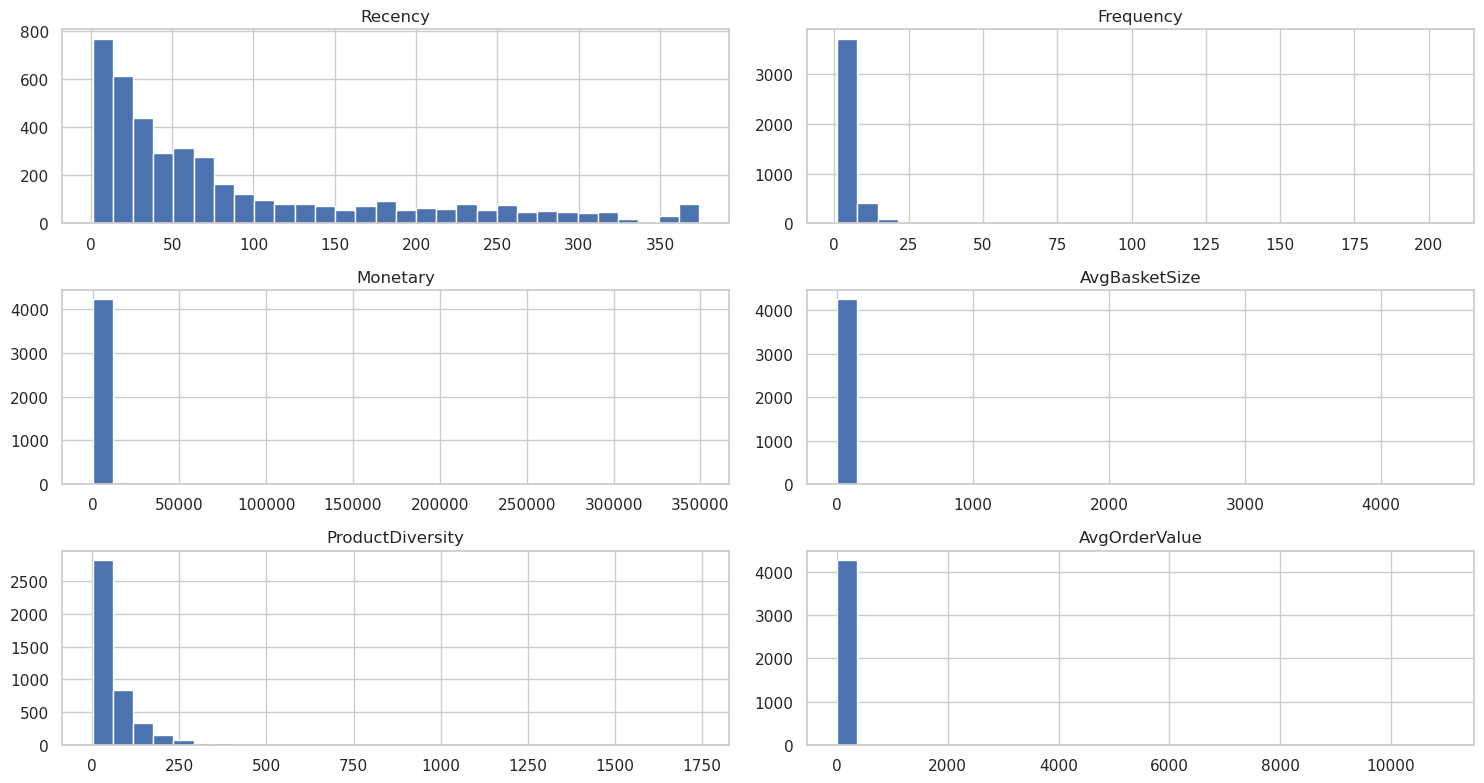

In [17]:
features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AvgBasketSize',
    'ProductDiversity',
    'AvgOrderValue'
]

rfm[features].hist(
    figsize=(15,8),
    bins=30
)

plt.tight_layout()
plt.show()

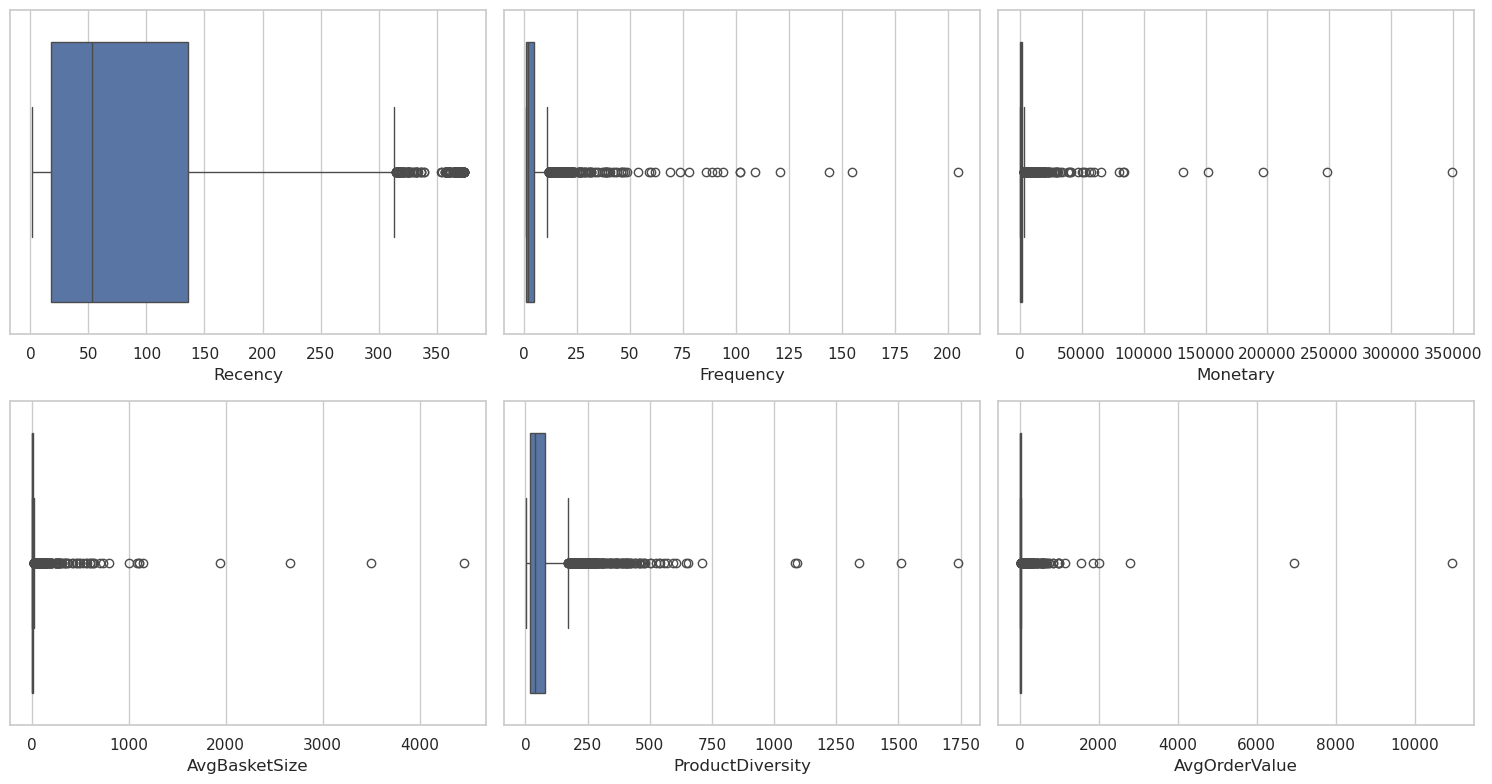

In [18]:
plt.figure(figsize=(15,8))

for i, col in enumerate(features, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x=rfm[col])

plt.tight_layout()
plt.show()

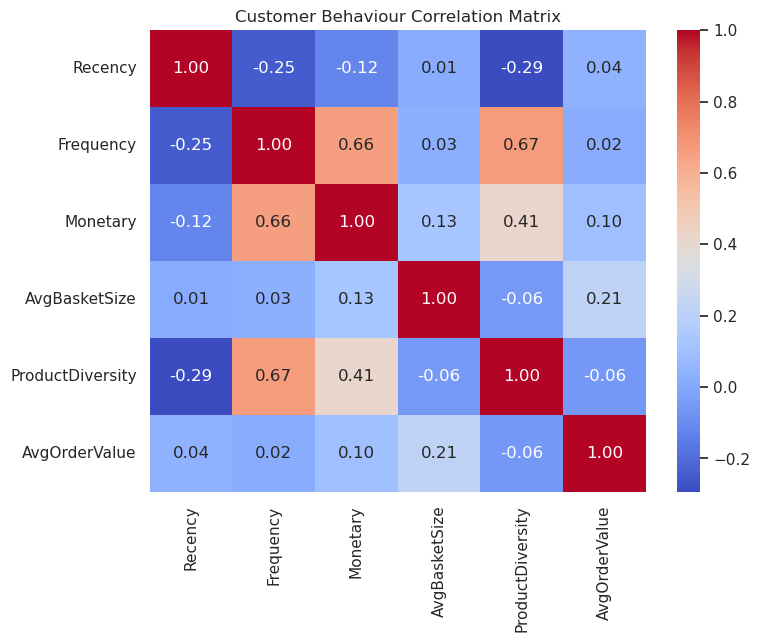

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    rfm[features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Customer Behaviour Correlation Matrix')
plt.show()

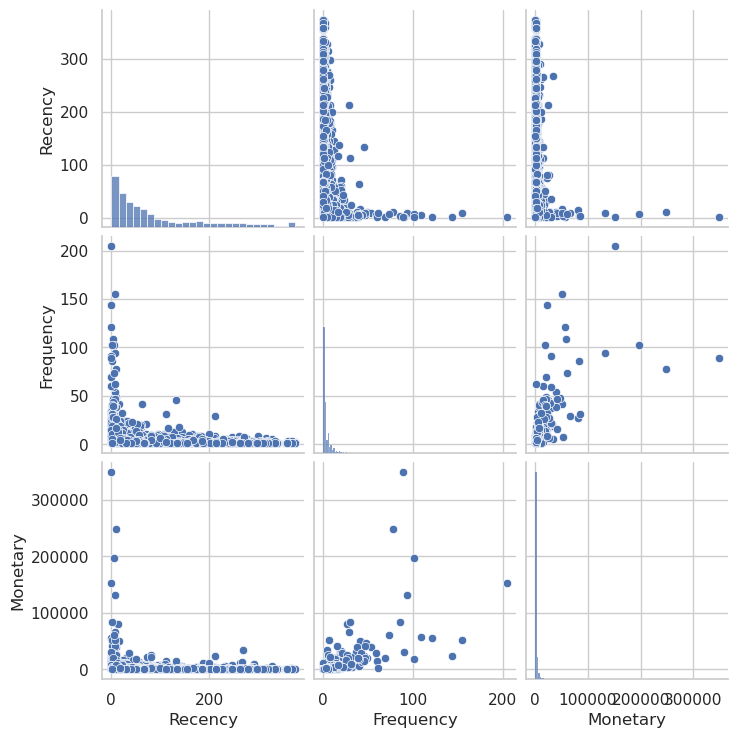

In [20]:
sns.pairplot(
    rfm[[
        'Recency',
        'Frequency',
        'Monetary'
    ]]
)

plt.show()

In [21]:
rfm.isnull().sum()

CustomerID          0
Recency             0
Frequency           0
Monetary            0
AvgBasketSize       0
ProductDiversity    0
AvgOrderValue       0
dtype: int64

In [22]:
rfm[features].skew().sort_values(
    ascending=False
)

AvgOrderValue       37.821679
AvgBasketSize       25.147718
Monetary            23.978464
Frequency           10.546821
ProductDiversity     6.150791
Recency              1.282928
dtype: float64

#### Key Trends, Patterns, and Insights

#### Distribution of Customer Behaviour Metrics

- All engineered features exhibit positively skewed distributions, indicating that most customers display relatively low activity while a small group demonstrates exceptionally high engagement and spending.
- Recency shows a moderate right skew (1.28), suggesting that most customers have purchased recently, while a smaller group has remained inactive for extended periods.
- Frequency, Monetary, AvgBasketSize, ProductDiversity, and AvgOrderValue are highly right-skewed, indicating the presence of a small number of highly active and valuable customers.

---

#### Customer Spending Patterns

- Monetary value is heavily concentrated among a small subset of customers.
- Most customers generate relatively low revenue, while a few customers contribute disproportionately high sales volumes.
- This pattern is typical of retail datasets and suggests the existence of premium or VIP customer segments.

---

#### Purchase Frequency and Engagement

- The majority of customers make only a small number of purchases.
- A limited number of customers purchase very frequently, with some customers appearing as extreme high-frequency buyers.
- These highly engaged customers are likely to be among the most valuable segments for retention and marketing efforts.

---

#### Product Diversity Behaviour

- ProductDiversity exhibits substantial variation across customers.
- Most customers purchase a relatively narrow range of products, while a small subset explores a significantly broader portion of the product catalog.
- Customers with higher product diversity tend to be more engaged with the business overall.

---

#### Correlation Analysis

##### Strong Positive Relationships

- Frequency and ProductDiversity show the strongest positive correlation (**0.67**).
  - Customers who purchase more frequently tend to buy a wider variety of products.

- Frequency and Monetary show a strong positive correlation (**0.66**).
  - Frequent purchasers generally contribute more revenue.

##### Moderate Relationships

- Monetary and ProductDiversity exhibit a moderate positive correlation (**0.41**).
  - Customers purchasing a broader range of products often generate higher spending.

##### Negative Relationships

- Recency has a negative relationship with Frequency (**-0.25**) and ProductDiversity (**-0.29**).
  - Recently active customers tend to purchase more frequently and explore more products.

##### Weak Relationships

- AvgBasketSize and AvgOrderValue show weak correlations with most other features.
  - These variables capture unique purchasing behaviors that are not fully explained by spending frequency or product diversity.

---

#### Outlier Analysis

- Boxplots reveal a substantial number of extreme outliers across Frequency, Monetary, AvgBasketSize, ProductDiversity, and AvgOrderValue.
- These observations likely represent genuine high-value customers rather than data quality issues.
- Because K-Means clustering is sensitive to feature scale and extreme values, feature scaling is essential before model training.

---

#### Pairplot Observations

- The pairwise plots confirm a positive relationship between Frequency and Monetary.
- Customers with higher purchase frequency generally exhibit higher spending levels.
- A small cluster of customers appears distinctly separated from the majority, suggesting the presence of naturally occurring customer segments.

---

#### Data Quality Assessment

- No missing values were found across any engineered features.
- The dataset is complete and suitable for clustering after appropriate feature scaling.

---

#### Implications for Customer Segmentation

The customer base demonstrates substantial heterogeneity in purchasing behavior, spending levels, product exploration, and engagement. The strong variation observed across all behavioral metrics indicates that meaningful customer segments are likely to exist. These characteristics make the dataset well-suited for unsupervised clustering techniques such as K-Means.

### 6. Preliminary Observations & Learnings

#### The analysis conducted so far reveals several important characteristics of the customer base and purchasing behavior.

#### Data Quality & Preparation

- Missing customer identifiers and incomplete product descriptions were successfully removed to ensure reliable customer-level analysis.
- Transactions with non-positive quantities or prices were excluded, eliminating returns, cancellations, and invalid records.
- The resulting dataset provides a clean representation of genuine purchasing activity.

---

#### Customer Behaviour Characteristics

- Customer purchasing behavior is highly uneven, with a small subset of customers contributing a disproportionately large share of transactions and revenue.
- Most customers purchase infrequently and generate relatively low spending, while a limited number of customers exhibit exceptionally high engagement and value.
- Customer activity levels vary significantly, indicating the presence of distinct behavioral groups.

---

#### Spending Patterns

- Revenue contribution is concentrated among a small number of customers.
- Monetary values exhibit extreme right-skewness, suggesting the existence of premium and high-value customers.
- The observed spending distribution follows a common retail pattern where a minority of customers generate the majority of sales.

---

#### Product Engagement

- Customers differ considerably in the variety of products they purchase.
- Highly engaged customers tend to explore a wider range of products compared to less active customers.
- Product diversity appears to be an important indicator of customer engagement.

---

#### Feature Relationships

- Purchase Frequency and Product Diversity demonstrate a strong positive relationship, suggesting that frequent customers tend to buy from a broader range of products.
- Frequency and Monetary Value are strongly correlated, indicating that repeat purchasing behavior is a major driver of customer value.
- Recency exhibits negative relationships with Frequency and Product Diversity, suggesting that recently active customers are generally more engaged.

---

#### Outlier Presence

- Significant outliers exist across Frequency, Monetary, AvgBasketSize, ProductDiversity, and AvgOrderValue.
- These observations likely represent genuine high-value customers rather than data quality issues.
- The presence of extreme values highlights the importance of feature transformation and scaling before clustering.

---

#### Readiness for Segmentation

- No missing values remain in the engineered feature set.
- The engineered features capture multiple dimensions of customer behavior, including recency, loyalty, spending power, purchasing volume, and product exploration.
- The clear variation observed across customers suggests strong potential for meaningful customer segmentation using clustering techniques.

---

#### Key Learning

The customer base is far from homogeneous. Significant differences exist in purchasing frequency, spending behavior, basket composition, and product preferences. These behavioral differences indicate that customers can likely be grouped into distinct segments, providing a strong foundation for the next stage of the project: customer clustering and segment profiling.

### 7. Planned Next Steps

#### The exploratory analysis confirms that the customer base exhibits significant variation in purchasing behavior, spending patterns, and product engagement. To transform these observations into actionable business insights, the next stages of the project will focus on customer segmentation and cluster profiling.

#### 1. Customer Behaviour Profiling

- Prepare the engineered customer-level features for clustering.
- Address the strong skewness observed in multiple features through appropriate transformations.
- Standardize feature scales to ensure fair contribution during clustering.

**Objective:** Create a robust representation of customer behavior suitable for unsupervised learning.

---

#### 2. Customer Micro-Segmentation using Clustering

- Apply K-Means clustering to identify groups of customers with similar behavioral characteristics.
- Experiment with multiple cluster sizes to determine the most meaningful segmentation structure.
- Assign each customer to a behavioral segment.

**Objective:** Discover naturally occurring customer groups based on purchasing patterns, spending habits, and engagement levels.

---

#### 3. Cluster Evaluation & Interpretation

- Evaluate clustering quality using techniques such as the Elbow Method and Silhouette Score.
- Analyze cluster centroids and feature distributions.
- Compare customer groups across Recency, Frequency, Monetary Value, Product Diversity, Basket Size, and Order Value.

**Objective:** Understand the defining characteristics of each customer segment and validate segmentation quality.

---

#### 4. Business Insights & Visualization

- Develop visual profiles for each customer segment.
- Identify high-value, loyal, at-risk, and low-engagement customer groups.
- Translate clustering results into actionable business recommendations.

Potential business applications include:

- Customer retention strategies
- Loyalty program optimization
- Personalized marketing campaigns
- Cross-selling and upselling opportunities
- Revenue growth initiatives

**Objective:** Convert analytical findings into practical business decisions and customer engagement strategies.

---

#### Expected Outcome

By the end of the project, customers will be grouped into meaningful behavioral segments, enabling a deeper understanding of customer value, engagement patterns, and purchasing preferences. These insights can support data-driven marketing, retention, and growth strategies.